In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import pandas as pd

PATH = "/kaggle/input/competitions/santander-customer-satisfaction/"

train = pd.read_csv(PATH + "train.csv")

X = train.drop(columns=["ID", "TARGET"])
y = train["TARGET"]

print("Shape:", X.shape)

Shape: (76020, 369)


In [3]:
# Drop constant columns
constant_cols = [col for col in X.columns if X[col].nunique() == 1]

X = X.drop(columns=constant_cols)

print("Dropped constant columns:", len(constant_cols))
print("New shape:", X.shape)

Dropped constant columns: 34
New shape: (76020, 335)


In [4]:
top_features = (
    X.corrwith(y)
    .abs()
    .sort_values(ascending=False)
    .head(30)
)

top_features_list = top_features.index.tolist()

print(top_features)

ind_var30                     0.149811
num_meses_var5_ult3           0.148253
num_var30                     0.138289
num_var42                     0.135693
ind_var5                      0.135349
num_var5                      0.134095
var36                         0.102919
var15                         0.101322
num_var4                      0.080194
num_var35                     0.076872
ind_var8_0                    0.046665
num_var8_0                    0.046622
ind_var13                     0.039612
ind_var13_0                   0.039471
num_var13                     0.038400
ind_var12_0                   0.038215
num_var13_0                   0.038045
saldo_var30                   0.037092
ind_var39_0                   0.035045
ind_var13_corto               0.034438
num_var13_corto               0.034432
num_meses_var13_corto_ult3    0.034367
ind_var13_corto_0             0.034337
ind_var12                     0.034255
num_var13_corto_0             0.034236
ind_var41_0              

In [5]:
selected_features = top_features_list

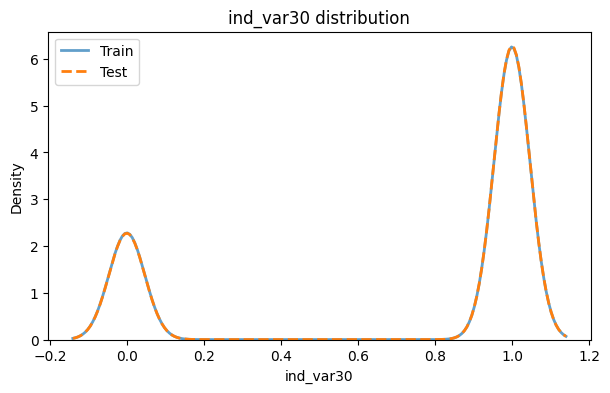

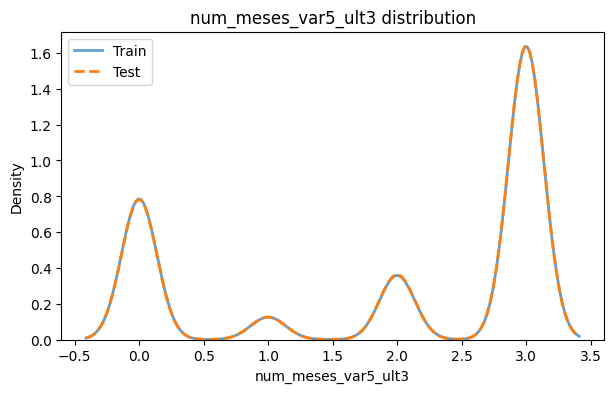

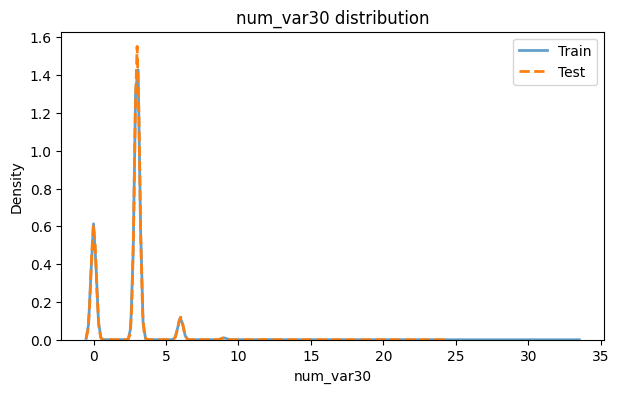

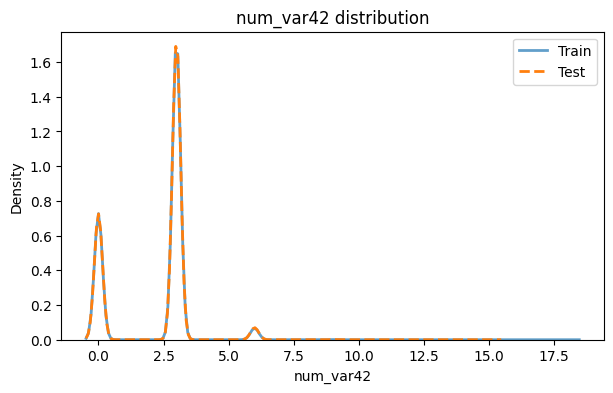

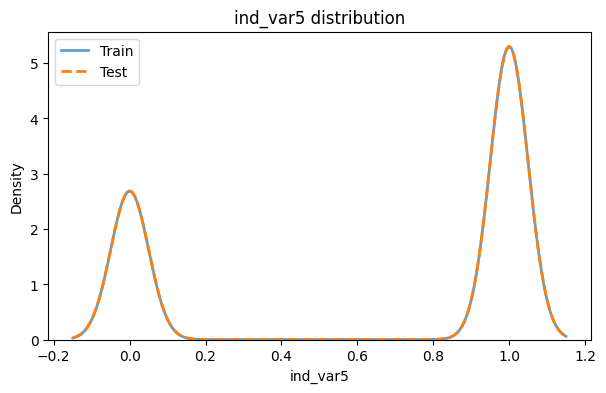

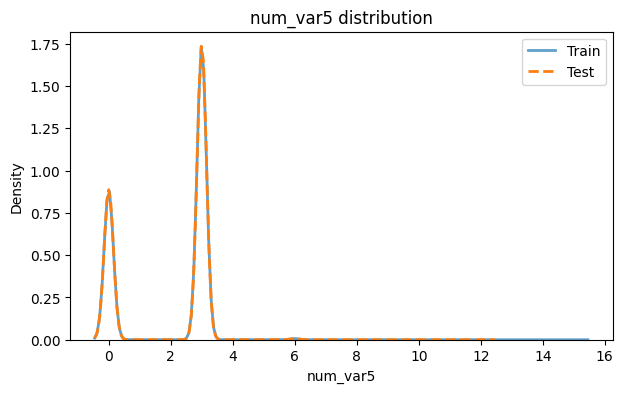

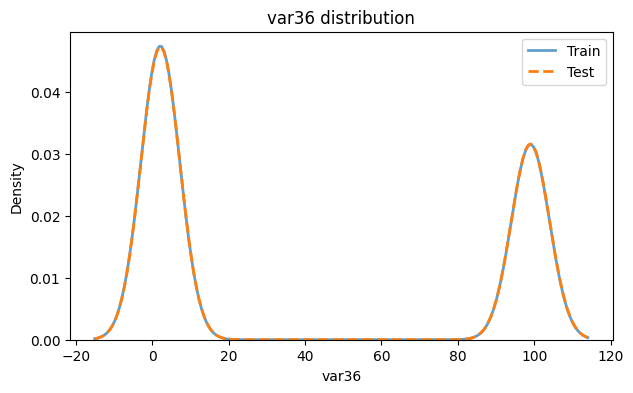

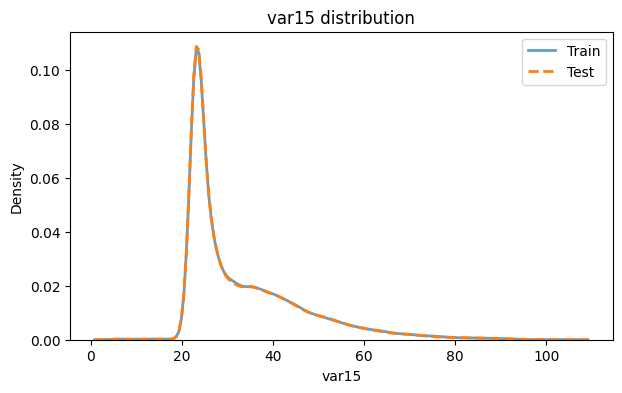

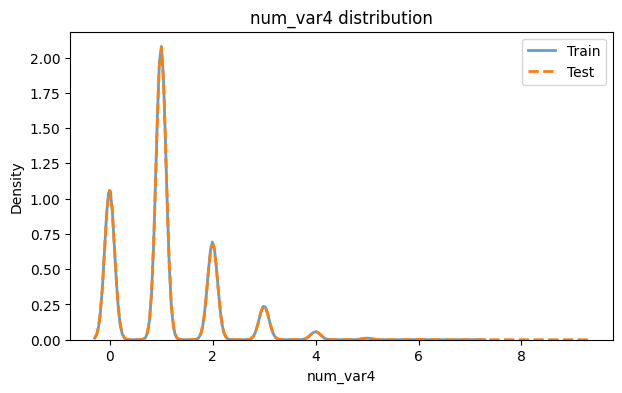

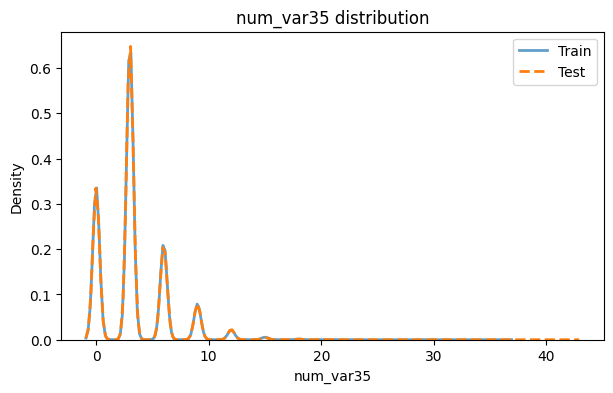

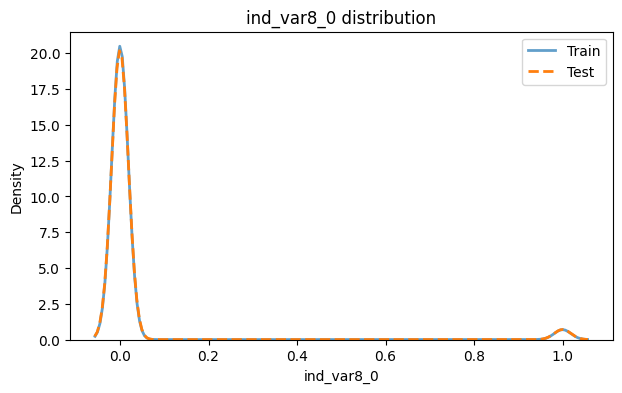

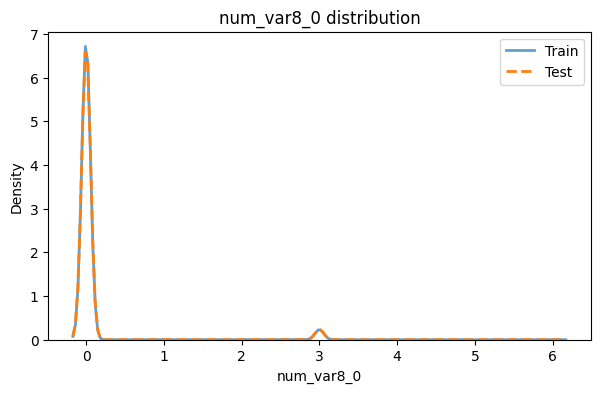

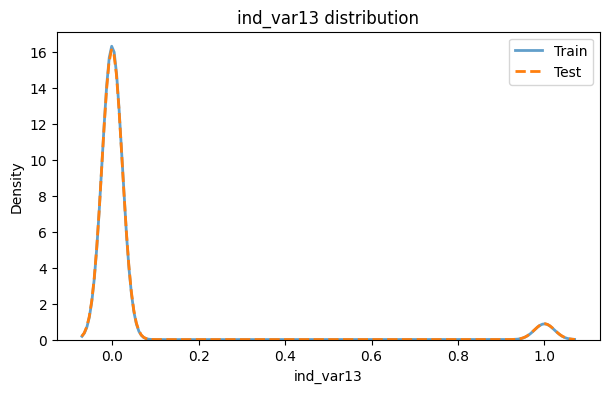

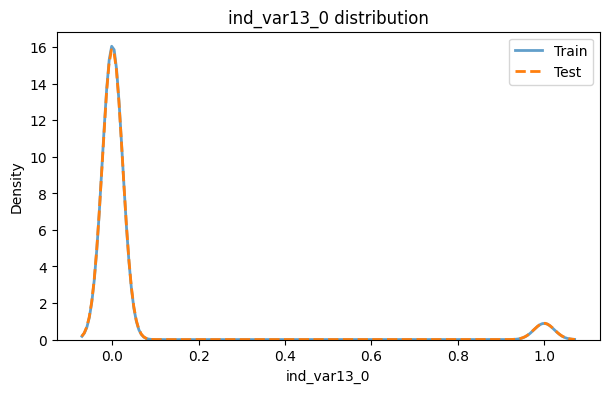

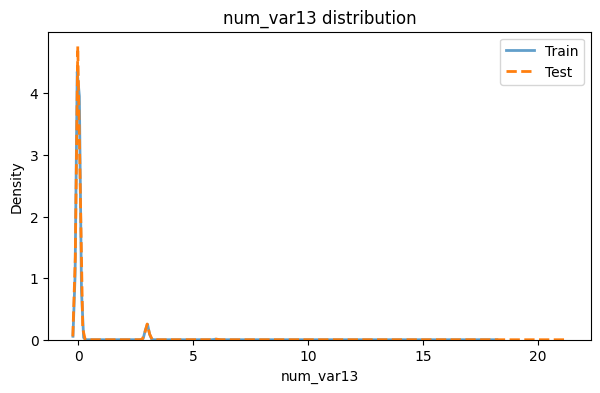

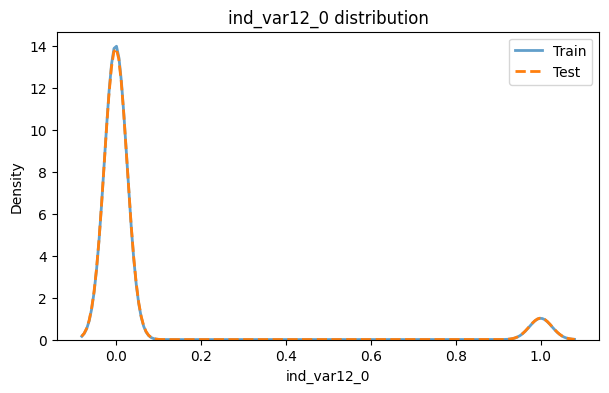

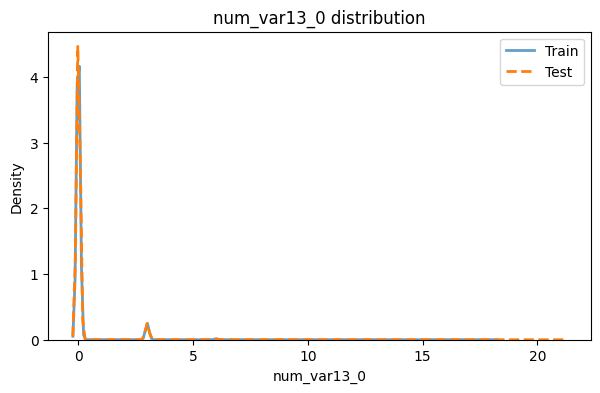

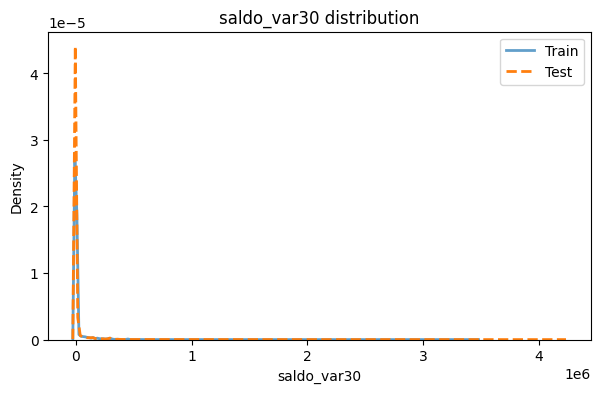

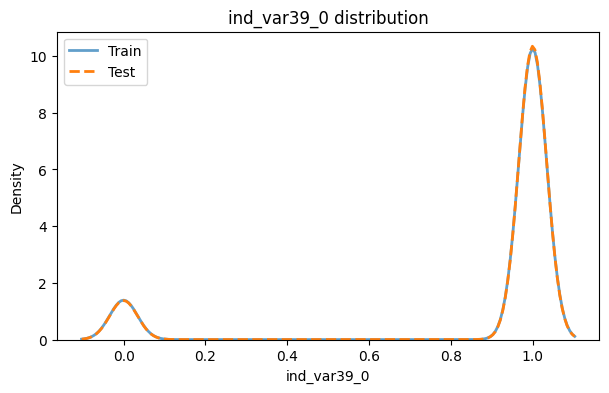

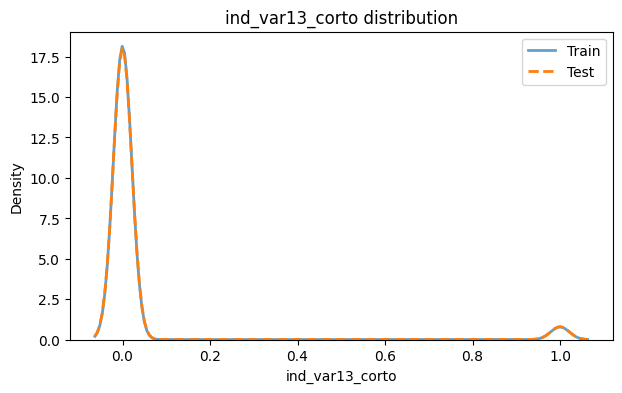

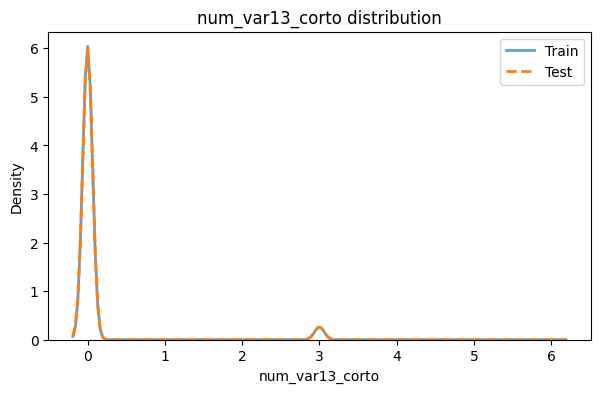

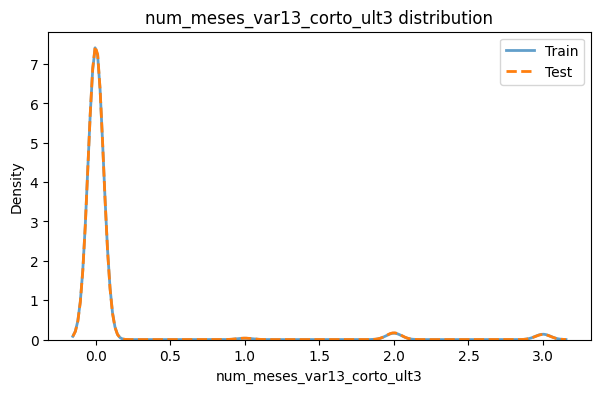

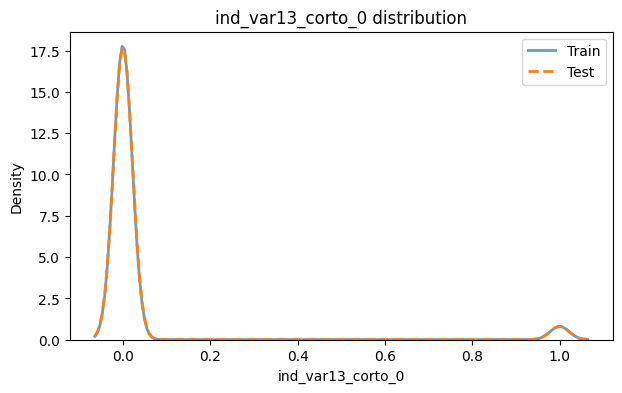

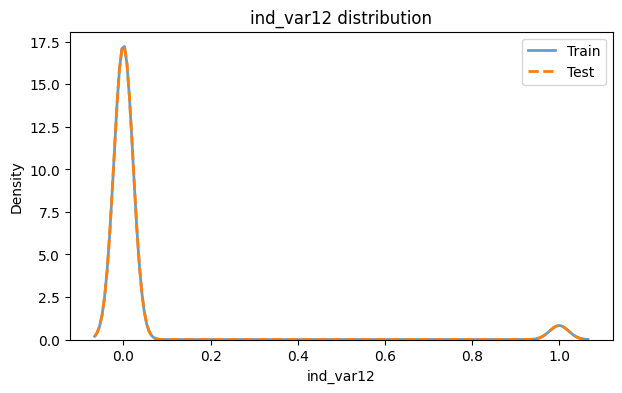

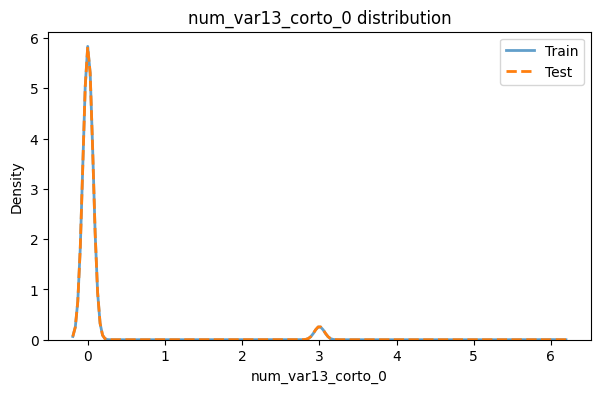

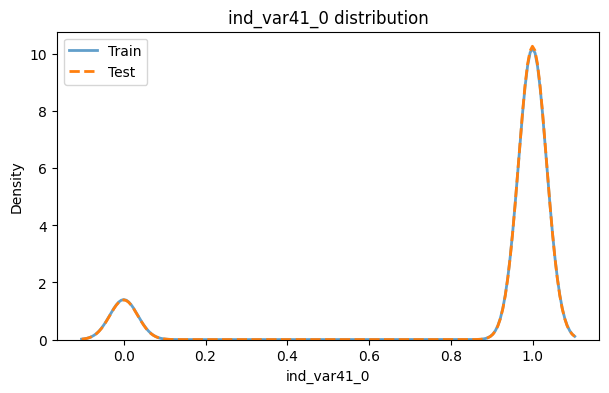

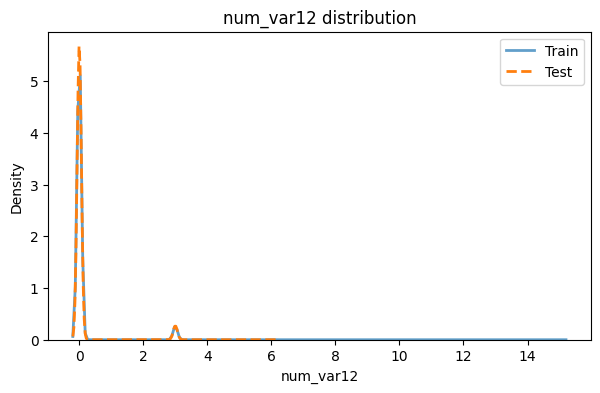

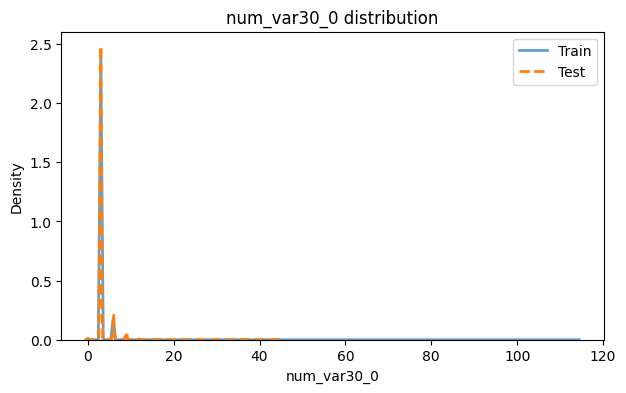

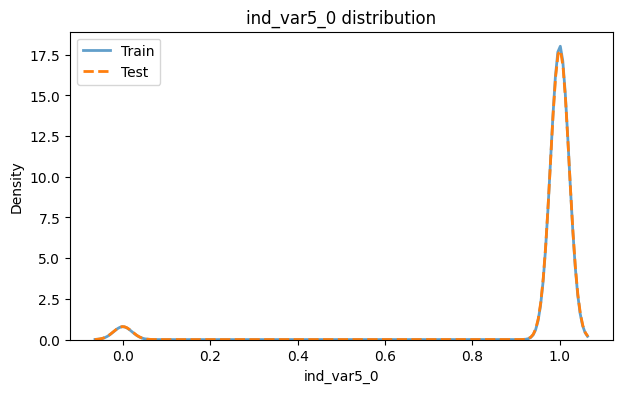

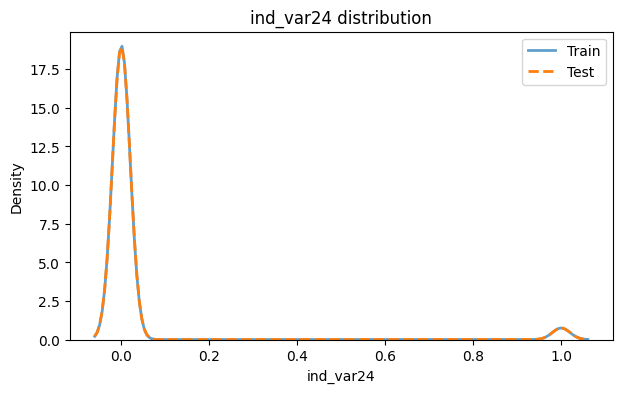

In [8]:
test = pd.read_csv(PATH + "test.csv")
X_test = test.drop(columns=["ID"])

import seaborn as sns
import matplotlib.pyplot as plt

for col in selected_features:
    plt.figure(figsize=(7,4))
    
    sns.kdeplot(X[col], label="Train", linewidth=2, alpha=0.7)
    sns.kdeplot(X_test[col], label="Test", linewidth=2, linestyle="--")
    
    plt.title(f"{col} distribution")
    plt.legend()
    plt.show()

In [9]:
constant_cols = [col for col in X.columns if X[col].nunique() == 1]

X = X.drop(columns=constant_cols)
X_test = X_test.drop(columns=constant_cols)

print("Dropped constant:", len(constant_cols))

Dropped constant: 0


In [10]:
sparse_cols = [col for col in X.columns if (X[col] == 0).mean() > 0.99]

X = X.drop(columns=sparse_cols)
X_test = X_test.drop(columns=sparse_cols)

print("Dropped sparse:", len(sparse_cols))

Dropped sparse: 186


In [11]:
import numpy as np

corr_matrix = X.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_cols = [col for col in upper.columns if any(upper[col] > 0.98)]

X = X.drop(columns=high_corr_cols)
X_test = X_test.drop(columns=high_corr_cols)

print("Dropped correlated:", len(high_corr_cols))

Dropped correlated: 38


In [12]:
X['var3_missing'] = (X['var3'] == -999999).astype(int)
X.loc[X['var3'] == -999999, 'var3'] = X['var3'].mode()[0]

X_test['var3_missing'] = (X_test['var3'] == -999999).astype(int)
X_test.loc[X_test['var3'] == -999999, 'var3'] = X_test['var3'].mode()[0]

In [13]:
X['var36_99_flag'] = (X['var36'] == 99).astype(int)
X_test['var36_99_flag'] = (X_test['var36'] == 99).astype(int)

In [14]:
X['var38_flag'] = (X['var38'] == 117310.979).astype(int)
X['var38'] = np.log1p(X['var38'])

X_test['var38_flag'] = (X_test['var38'] == 117310.979).astype(int)
X_test['var38'] = np.log1p(X_test['var38'])

In [15]:
X['is_young'] = (X['var15'] < 23).astype(int)
X_test['is_young'] = (X_test['var15'] < 23).astype(int)

In [23]:
top_features = (
    X.corrwith(y)
    .abs()
    .sort_values(ascending=False)
    .head(100)
)

selected_features = top_features.index.tolist()

X = X[selected_features]
X_test = X_test[selected_features]

print("Final shape:", X.shape)

Final shape: (76020, 100)


In [26]:
selected_features = X.columns.tolist()
print(selected_features)

['ind_var30', 'num_meses_var5_ult3', 'num_var30', 'num_var42', 'ind_var5', 'var36_99_flag', 'var36', 'var15', 'num_var4', 'var38', 'ind_var8_0', 'ind_var13_0', 'num_var13', 'ind_var12_0', 'num_var13_0', 'saldo_var30', 'ind_var39_0', 'num_meses_var13_corto_ult3', 'ind_var13_corto_0', 'ind_var12', 'num_var30_0', 'ind_var5_0', 'ind_var24', 'num_meses_var12_ult3', 'num_var41_0', 'ind_var24_0', 'saldo_var13', 'imp_op_var41_efect_ult1', 'num_var39_0', 'num_var5_0', 'ind_var8', 'imp_op_var41_ult1', 'num_aport_var13_hace3', 'num_meses_var8_ult3', 'saldo_var13_corto', 'is_young', 'num_var12_0', 'num_var22_ult1', 'saldo_var42', 'ind_var26_cte', 'ind_var25_cte', 'saldo_medio_var13_corto_hace2', 'saldo_var12', 'imp_op_var41_efect_ult3', 'ind_var43_recib_ult1', 'num_op_var41_efect_ult1', 'imp_aport_var13_hace3', 'saldo_medio_var5_hace2', 'ind_var14_0', 'num_op_var41_efect_ult3', 'ind_var25_0', 'ind_var13_largo_0', 'ind_var26_0', 'saldo_medio_var5_ult3', 'num_var25_0', 'num_var26_0', 'num_var42_0', 

In [25]:
selected_features = [f for f in selected_features if f not in constant_features]

In [21]:
constant_features = [col for col in X.columns if X[col].nunique() == 1]

In [27]:
sparse_cols = [col for col in X.columns if (X[col] == 0).mean() > 0.99]

print("Sparse features:", len(sparse_cols))

Sparse features: 1


In [28]:
import numpy as np

corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_cols = [col for col in upper.columns if any(upper[col] > 0.98)]

print("Highly correlated:", len(high_corr_cols))

Highly correlated: 1


In [29]:
print("Final feature count:", X.shape[1])

Final feature count: 100


In [30]:
for i, col in enumerate(X.columns):
    print(f"{i+1}. {col}")

1. ind_var30
2. num_meses_var5_ult3
3. num_var30
4. num_var42
5. ind_var5
6. var36_99_flag
7. var36
8. var15
9. num_var4
10. var38
11. ind_var8_0
12. ind_var13_0
13. num_var13
14. ind_var12_0
15. num_var13_0
16. saldo_var30
17. ind_var39_0
18. num_meses_var13_corto_ult3
19. ind_var13_corto_0
20. ind_var12
21. num_var30_0
22. ind_var5_0
23. ind_var24
24. num_meses_var12_ult3
25. num_var41_0
26. ind_var24_0
27. saldo_var13
28. imp_op_var41_efect_ult1
29. num_var39_0
30. num_var5_0
31. ind_var8
32. imp_op_var41_ult1
33. num_aport_var13_hace3
34. num_meses_var8_ult3
35. saldo_var13_corto
36. is_young
37. num_var12_0
38. num_var22_ult1
39. saldo_var42
40. ind_var26_cte
41. ind_var25_cte
42. saldo_medio_var13_corto_hace2
43. saldo_var12
44. imp_op_var41_efect_ult3
45. ind_var43_recib_ult1
46. num_op_var41_efect_ult1
47. imp_aport_var13_hace3
48. saldo_medio_var5_hace2
49. ind_var14_0
50. num_op_var41_efect_ult3
51. ind_var25_0
52. ind_var13_largo_0
53. ind_var26_0
54. saldo_medio_var5_ult3
5

In [31]:
import pandas as pd

# Convert feature list to DataFrame
features_df = pd.DataFrame({
    "feature_name": X.columns
})

# Save as CSV
features_df.to_csv("Top100_selected_features.csv", index=False)

print("CSV file created successfully!")

CSV file created successfully!
